In [ ]:
import sys
print(sys.executable)
%pip install -U async-timeout aiohttp

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = ''
# os.environ['HF_HOME'] = ''

import json
from PIL import Image
import matplotlib.pyplot as plt
import argparse
from datetime import datetime
import numpy as np
import sys
sys.path.append('fkd_diffusers')

import torch
from diffusers import DDIMScheduler

from launch_eval_runs import do_eval

/home/adalal542/.conda/envs/fk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set args
"""
model_choices:

stable-diffusion-xl
stable-diffusion-v1-5
stable-diffusion-v1-4
stable-diffusion-2-1
"""

args = dict(
    seed=42,
    output_dir="output", 
    eta=1.0,
    metrics_to_compute="GroundingDINOSpatial", #"Clip-Score", #
    prompt_path='./prompt_files/benchmark_ir.json',#'./prompt_files/image_rewards_benchmark.json', 
    model_name="stable-diffusion-xl", 
  )

fkd_args = dict(
    lmbda=2.0,
    num_particles=8,
    adaptive_resampling=True,
    resample_frequency=20,
    time_steps=100,
    potential_type='max',
    resampling_t_start=20,
    resampling_t_end=50,
    guidance_reward_fn='GroundingDINOSpatial', #'Clip-Score',
    use_smc=True,
    reward_history=[],
    record_reward_history=True,
   )

args = argparse.Namespace(**args, **fkd_args)
args

Namespace(seed=42, output_dir='output', eta=1.0, metrics_to_compute='GroundingDINOSpatial', prompt_path='./prompt_files/benchmark_ir.json', model_name='stable-diffusion-xl', lmbda=2.0, num_particles=8, adaptive_resampling=True, resample_frequency=20, time_steps=100, potential_type='max', resampling_t_start=20, resampling_t_end=50, guidance_reward_fn='GroundingDINOSpatial', use_smc=True, reward_history=[], record_reward_history=True)

In [3]:
args.num_inference_steps = fkd_args["time_steps"]
fkd_args["reward_config"] = {
    # detection
    "box_threshold": 0.3,              # base threshold outside steering window
    "text_threshold": 0.25,
    "use_soft_detections": True,
    "soft_box_threshold": 0.05,         # low threshold for soft cues
    "use_step_box_threshold_schedule": True,
    "steering_phase_start_ratio": 0.15, # ~step 15/100
    "steering_phase_end_ratio": 0.45,   # ~step 45/100
    "steering_phase_box_threshold": 0.05,

    # reward mixing (base; dynamic schedule overrides per-step)
    "relation_weight": 0.45,
    "object_count_weight": 0.55,
    "dynamic_stage_weighting": True,
    "stage_transition_progress": 0.6,
    "stage_sharpness": 10.0,
    "stage_early_object_fraction": 0.45,
    "stage_early_object_boost": 3.5,

    # relation scoring
    "relation_scoring_mode": "gaussian",
    "relation_gaussian_sigma": 0.3,

    # inventory strictness
    "inventory_aggregate": "min",

    # temporal consistency (reduce assignment flicker)
    "temporal_consistency_weight": 0.3,
    "temporal_tiebreak_weight": 0.25,
    "temporal_sigma": 0.08,
}
# fkd_args["reward_config"] = {
#     "box_threshold": 0.05,
#     "text_threshold": 0.25,
#     "align_scale": 6.0,
#     "relation_weight": 0.9,
#     "object_count_weight": 0.1,
#     # optional explicit relations per image:
#     # "spatial_relations": [[{"subject":"cat","object":"chair","relation":"left_of"}]]
# }
fkd_args

{'lmbda': 2.0,
 'num_particles': 8,
 'adaptive_resampling': True,
 'resample_frequency': 20,
 'time_steps': 100,
 'potential_type': 'max',
 'resampling_t_start': 20,
 'resampling_t_end': 50,
 'guidance_reward_fn': 'GroundingDINOSpatial',
 'use_smc': True,
 'reward_history': [],
 'record_reward_history': True,
 'reward_config': {'box_threshold': 0.3,
  'text_threshold': 0.25,
  'use_soft_detections': True,
  'soft_box_threshold': 0.05,
  'use_step_box_threshold_schedule': True,
  'steering_phase_start_ratio': 0.15,
  'steering_phase_end_ratio': 0.45,
  'steering_phase_box_threshold': 0.05,
  'relation_weight': 0.45,
  'object_count_weight': 0.55,
  'dynamic_stage_weighting': True,
  'stage_transition_progress': 0.6,
  'stage_sharpness': 10.0,
  'stage_early_object_fraction': 0.45,
  'stage_early_object_boost': 3.5,
  'relation_scoring_mode': 'gaussian',
  'relation_gaussian_sigma': 0.3,
  'inventory_aggregate': 'min',
  'temporal_consistency_weight': 0.3,
  'temporal_tiebreak_weight': 0

In [4]:
# seed everything
torch.manual_seed(args.seed)
torch.cuda.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)

In [5]:
device = "cuda"

In [6]:
from fks_utils import get_model

pipeline = get_model(args.model_name)
pipeline = pipeline.to(device)    

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  4.10it/s]


In [7]:
# set output directory
cur_time = datetime.now().strftime("%Y%m%d-%H%M%S")
output_dir = os.path.join(args.output_dir, cur_time)
os.makedirs(output_dir, exist_ok=False)
arg_path = os.path.join(output_dir, "args.json")
with open(arg_path, "w") as f:
    json.dump(vars(args), f, indent=4)

score_path = os.path.join(output_dir, "scores.jsonl")
images_path = os.path.join(output_dir, "images")
os.makedirs(images_path, exist_ok=False)

metrics_to_compute = args.metrics_to_compute.split("#")


# cache metric fns
do_eval(
    prompt=["a cat left of a chair"],
    images=[Image.new("RGB", (224, 224))],
    metrics_to_compute=metrics_to_compute,
    )


/scratch/adalal542/Fk-Diffusion-Steering/text_to_image/fks_utils.py:127: UserWarning: Grounding DINO in Transformers may log missing MSDeformAttn CUDA sources (vision.cpp). A slower PyTorch fallback is used; those messages are usually harmless.
  results[metric]["result"] = do_grounding_dino_spatial_reward(
/home/adalal542/.conda/envs/fk/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Could not load the custom kernel for multi-scale deformable attention: [Errno 2] No such file or directory: '/scratch/adalal542/.conda/envs/fk/lib/python3.10/site-packages/transformers/kernels/grounding_dino/vision.cpp'
Could not load the custom kernel for multi-scale deformable attention: [Errno 2] No such file or directory: '/scratch/adalal542/.conda/envs/fk/lib/python3.10/site-packa

{'GroundingDINOSpatial': {'result': [-0.11000000000000001],
  'mean': -0.10999999940395355,
  'std': 0.0,
  'max': -0.10999999940395355,
  'min': -0.10999999940395355}}

In [8]:
# add prompts for generation
prompt_data = [
    {"prompt": "a cat to the left of a dog"},
    # {"prompt": "a cat on top of a dog"},
    # {"prompt": "a dog to the right of a cat"},
    # {"prompt": "a dog below a cat"},
    {"prompt": "a cat to the left of two dogs"},
    {"prompt": "a cat to the right of a dog and a bird"},
    {"prompt": "a coffee mug on top of a book next to a laptop that are all on a table"}
    # {"prompt": "a photo of a brown knife and a blue donut"},
    # {"prompt": "a photo of a blue clock and a white cup"},
    # {"prompt": "a photo of an orange cow and a purple sandwich"},
    # {"prompt": "a photo of a yellow bird and a black motorcycle"},
    # {"prompt": "a photo of a green tennis racket and a black dog"},
    # {"prompt": "a green stop sign in a red field"},    
]
len(prompt_data)

4

In [9]:
show_best_particle = True
guidance_func = fkd_args["guidance_reward_fn"]
print(guidance_func)

GroundingDINOSpatial


Args: {'lmbda': 2.0, 'num_particles': 8, 'adaptive_resampling': True, 'resample_frequency': 20, 'time_steps': 100, 'potential_type': 'max', 'resampling_t_start': 20, 'resampling_t_end': 50, 'guidance_reward_fn': 'GroundingDINOSpatial', 'use_smc': True, 'reward_history': [], 'record_reward_history': True, 'reward_config': {'box_threshold': 0.3, 'text_threshold': 0.25, 'use_soft_detections': True, 'soft_box_threshold': 0.05, 'use_step_box_threshold_schedule': True, 'steering_phase_start_ratio': 0.15, 'steering_phase_end_ratio': 0.45, 'steering_phase_box_threshold': 0.05, 'relation_weight': 0.45, 'object_count_weight': 0.55, 'dynamic_stage_weighting': True, 'stage_transition_progress': 0.6, 'stage_sharpness': 10.0, 'stage_early_object_fraction': 0.45, 'stage_early_object_boost': 3.5, 'relation_scoring_mode': 'gaussian', 'relation_gaussian_sigma': 0.3, 'inventory_aggregate': 'min', 'temporal_consistency_weight': 0.3, 'temporal_tiebreak_weight': 0.25, 'temporal_sigma': 0.08}, 'grounding_ove

 20%|██        | 20/100 [00:06<00:25,  3.18it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


/scratch/adalal542/Fk-Diffusion-Steering/text_to_image/fkd_diffusers/rewards.py:53: UserWarning: Grounding DINO in Transformers may log missing MSDeformAttn CUDA sources (vision.cpp). A slower PyTorch fallback is used; those messages are usually harmless.
  return do_grounding_dino_spatial_reward(
/home/adalal542/.conda/envs/fk/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Could not load the custom kernel for multi-scale deformable attention: [Errno 2] No such file or directory: '/scratch/adalal542/.conda/envs/fk/lib/python3.10/site-packages/transformers/kernels/grounding_dino/vision.cpp'
Could not load the custom kernel for multi-scale deformable attention: [Errno 2] No such file or directory: '/scratch/adalal542/.conda/envs/fk/lib/python3.10/site-packages/transf

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 99%|█████████▉| 99/100 [00:42<00:00,  3.17it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


100%|██████████| 100/100 [00:48<00:00,  2.06it/s]


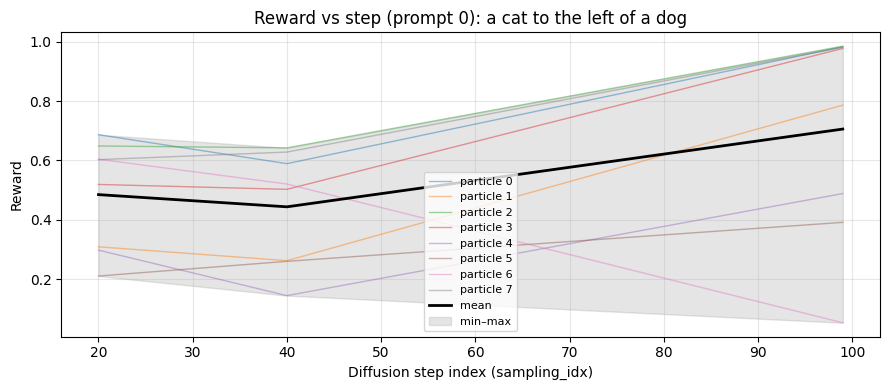

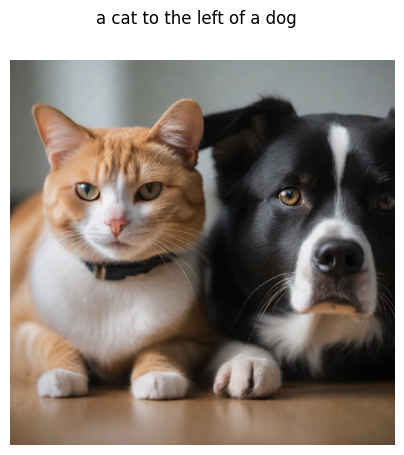

Args: {'lmbda': 2.0, 'num_particles': 8, 'adaptive_resampling': True, 'resample_frequency': 20, 'time_steps': 100, 'potential_type': 'max', 'resampling_t_start': 20, 'resampling_t_end': 50, 'guidance_reward_fn': 'GroundingDINOSpatial', 'use_smc': True, 'reward_history': [], 'record_reward_history': True, 'reward_config': {'box_threshold': 0.3, 'text_threshold': 0.25, 'use_soft_detections': True, 'soft_box_threshold': 0.05, 'use_step_box_threshold_schedule': True, 'steering_phase_start_ratio': 0.15, 'steering_phase_end_ratio': 0.45, 'steering_phase_box_threshold': 0.05, 'relation_weight': 0.45, 'object_count_weight': 0.55, 'dynamic_stage_weighting': True, 'stage_transition_progress': 0.6, 'stage_sharpness': 10.0, 'stage_early_object_fraction': 0.45, 'stage_early_object_boost': 3.5, 'relation_scoring_mode': 'gaussian', 'relation_gaussian_sigma': 0.3, 'inventory_aggregate': 'min', 'temporal_consistency_weight': 0.3, 'temporal_tiebreak_weight': 0.25, 'temporal_sigma': 0.08, 'temporal_state

 20%|██        | 20/100 [00:06<00:25,  3.16it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 40%|████      | 40/100 [00:17<00:18,  3.16it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 99%|█████████▉| 99/100 [00:41<00:00,  3.18it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


100%|██████████| 100/100 [00:46<00:00,  2.13it/s]


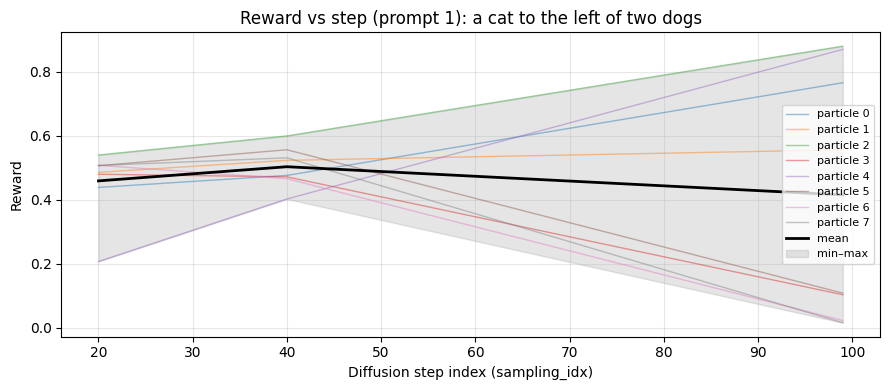

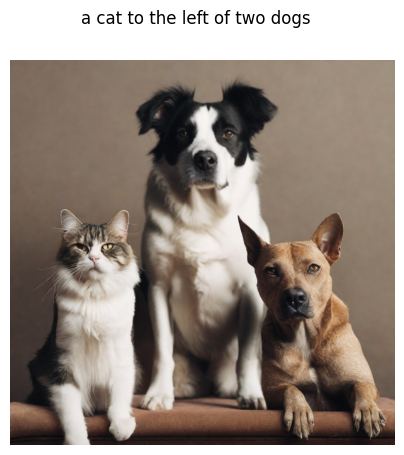

Args: {'lmbda': 2.0, 'num_particles': 8, 'adaptive_resampling': True, 'resample_frequency': 20, 'time_steps': 100, 'potential_type': 'max', 'resampling_t_start': 20, 'resampling_t_end': 50, 'guidance_reward_fn': 'GroundingDINOSpatial', 'use_smc': True, 'reward_history': [], 'record_reward_history': True, 'reward_config': {'box_threshold': 0.3, 'text_threshold': 0.25, 'use_soft_detections': True, 'soft_box_threshold': 0.05, 'use_step_box_threshold_schedule': True, 'steering_phase_start_ratio': 0.15, 'steering_phase_end_ratio': 0.45, 'steering_phase_box_threshold': 0.05, 'relation_weight': 0.45, 'object_count_weight': 0.55, 'dynamic_stage_weighting': True, 'stage_transition_progress': 0.6, 'stage_sharpness': 10.0, 'stage_early_object_fraction': 0.45, 'stage_early_object_boost': 3.5, 'relation_scoring_mode': 'gaussian', 'relation_gaussian_sigma': 0.3, 'inventory_aggregate': 'min', 'temporal_consistency_weight': 0.3, 'temporal_tiebreak_weight': 0.25, 'temporal_sigma': 0.08, 'temporal_state

 20%|██        | 20/100 [00:06<00:25,  3.17it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 40%|████      | 40/100 [00:17<00:19,  3.15it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 99%|█████████▉| 99/100 [00:40<00:00,  3.18it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


100%|██████████| 100/100 [00:45<00:00,  2.19it/s]


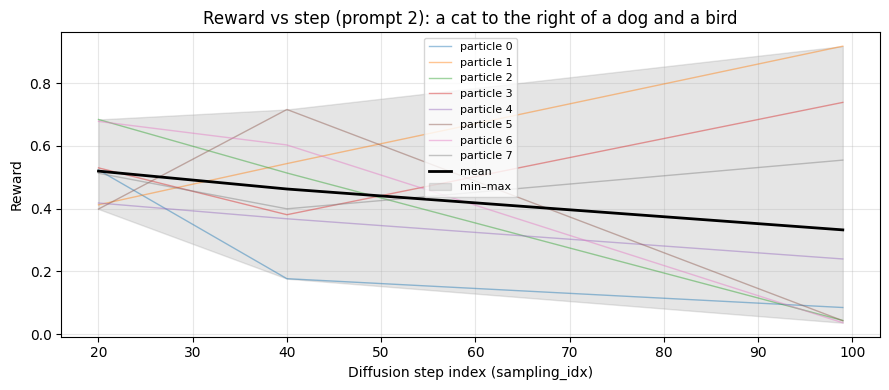

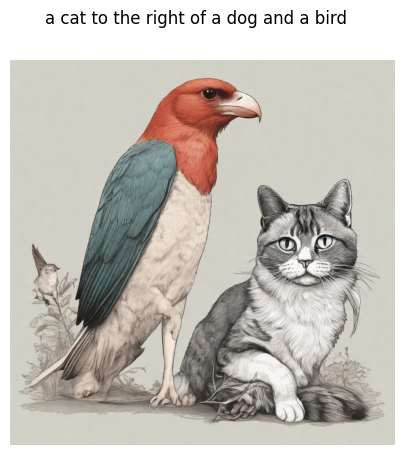

Args: {'lmbda': 2.0, 'num_particles': 8, 'adaptive_resampling': True, 'resample_frequency': 20, 'time_steps': 100, 'potential_type': 'max', 'resampling_t_start': 20, 'resampling_t_end': 50, 'guidance_reward_fn': 'GroundingDINOSpatial', 'use_smc': True, 'reward_history': [], 'record_reward_history': True, 'reward_config': {'box_threshold': 0.3, 'text_threshold': 0.25, 'use_soft_detections': True, 'soft_box_threshold': 0.05, 'use_step_box_threshold_schedule': True, 'steering_phase_start_ratio': 0.15, 'steering_phase_end_ratio': 0.45, 'steering_phase_box_threshold': 0.05, 'relation_weight': 0.45, 'object_count_weight': 0.55, 'dynamic_stage_weighting': True, 'stage_transition_progress': 0.6, 'stage_sharpness': 10.0, 'stage_early_object_fraction': 0.45, 'stage_early_object_boost': 3.5, 'relation_scoring_mode': 'gaussian', 'relation_gaussian_sigma': 0.3, 'inventory_aggregate': 'min', 'temporal_consistency_weight': 0.3, 'temporal_tiebreak_weight': 0.25, 'temporal_sigma': 0.08, 'temporal_state

 20%|██        | 20/100 [00:06<00:25,  3.16it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 40%|████      | 40/100 [00:17<00:19,  3.16it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


 99%|█████████▉| 99/100 [00:41<00:00,  3.18it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`


100%|██████████| 100/100 [00:47<00:00,  2.09it/s]


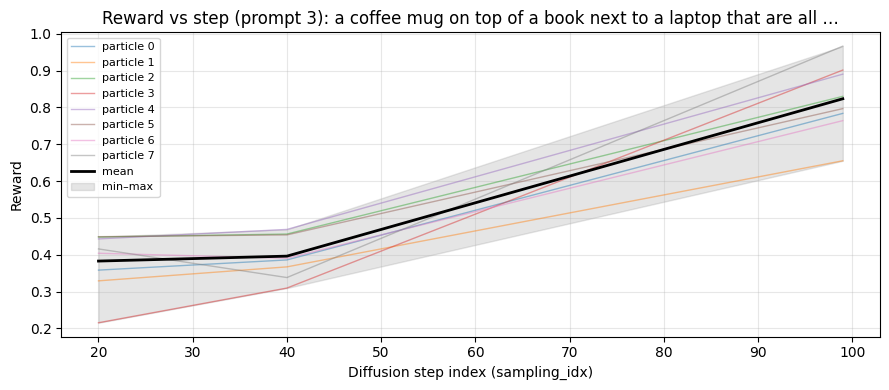

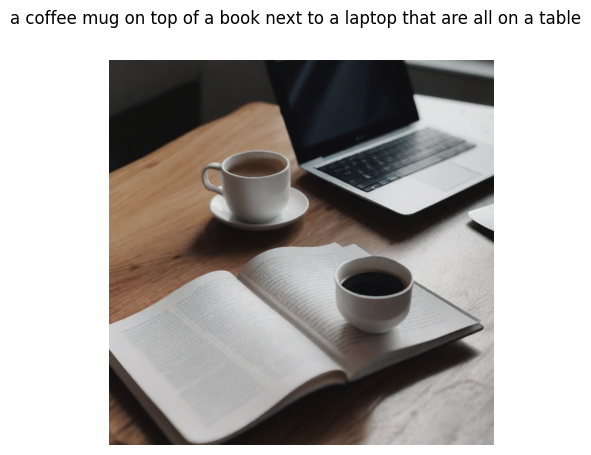

In [10]:
from fks_utils import plot_fkd_reward_trace

# FK steering only: reward_fn runs at resample steps; trace is saved per prompt.
plot_fkd_reward_trace_enabled = fkd_args.get("use_smc", False)

plots_dir = os.path.join(output_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

with open(score_path, "w") as score_f:
    for prompt_idx, item in enumerate(prompt_data):

        prompt = [item['prompt']] * fkd_args['num_particles']
        start_time = datetime.now()

        if plot_fkd_reward_trace_enabled:
            fkd_args["record_reward_history"] = True
            fkd_args["reward_history"] = []

        if fkd_args.get("guidance_reward_fn") == "GroundingDINOSpatial":
            go = os.path.join(plots_dir, "grounding_overlays", f"prompt_{prompt_idx:04d}")
            fkd_args["grounding_overlay_dir"] = go
            os.makedirs(go, exist_ok=True)
        else:
            fkd_args.pop("grounding_overlay_dir", None)

        images = pipeline(
            prompt,
            num_inference_steps=fkd_args["time_steps"],
            eta=args.eta,
            fkd_args=fkd_args,
        )
        end_time = datetime.now()
        images = images[0]

        time_taken = end_time - start_time

        results = do_eval(
            prompt=prompt,
            images=images,
            metrics_to_compute=metrics_to_compute,
            reward_config=fkd_args.get("reward_config") or {},
        )
        guidance_reward = np.array(results[guidance_func]["result"])
        sorted_idx = np.argsort(guidance_reward)[::-1]
        images = [images[i] for i in sorted_idx]

        results["time_taken"] = time_taken.total_seconds()
        results["prompt"] = prompt
        results["prompt_index"] = prompt_idx

        image_fpath = os.path.join(images_path, f"{prompt_idx}.png")
        results["image_path"] = image_fpath
        if fkd_args.get("grounding_overlay_dir"):
            results["grounding_overlay_dir"] = fkd_args["grounding_overlay_dir"]

        if plot_fkd_reward_trace_enabled and fkd_args.get("reward_history"):
            results["reward_plots_dir"] = plots_dir
            trace = list(fkd_args["reward_history"])
            trace_json = os.path.join(plots_dir, f"reward_trace_{prompt_idx:04d}.json")
            with open(trace_json, "w") as tf:
                json.dump(trace, tf, indent=2)
            results["reward_trace_path"] = trace_json
            trace_plot = os.path.join(plots_dir, f"reward_trace_{prompt_idx:04d}.png")
            _trace_title = (
                f"Reward vs step (prompt {prompt_idx}): {prompt[0][:60]}…"
                if len(prompt[0]) > 60
                else f"Reward vs step (prompt {prompt_idx}): {prompt[0]}"
            )
            fig_trace = plot_fkd_reward_trace(
                trace,
                title=_trace_title,
                save_path=trace_plot,
            )
            if fig_trace is not None:
                plt.show()
                plt.close(fig_trace)

        score_f.write(json.dumps(results, default=str) + "\n")

        if show_best_particle:
            _, ax = plt.subplots(1, 1, figsize=(5, 5))
            ax.imshow(images[0])
            ax.axis("off")
        else:
            _, ax = plt.subplots(1, args.num_particles, figsize=(args.num_particles * 5, 5))
            for i, image in enumerate(images):
                ax[i].imshow(image)
                ax[i].axis("off")

        plt.suptitle(prompt[0])
        plt.savefig(image_fpath)
        plt.show()
        plt.close()
